## CNN Cleaner

In [1]:
import pickle
import numpy as np
import tensorflow as tf

# ===== 1. load model =====
model = tf.keras.models.load_model(
    "/home/cyc/software/astroAI/models/crta_models/cleaner_z20.h5"
)

print("Model loaded")

# ===== 2. load dataset =====
with open("/home/cyc/software/astroAI/dataset/simulations_dataset_v1/dl3_z20_irf/z20_clean_test.pickle", "rb") as f:
    ds = pickle.load(f)

print("Keys:", ds.keys())

# cleaner 数据结构：DS1 = noisy, DS2 = clean
x = ds["DS1"]  # noisy input
y = ds["DS2"]  # target (optional)

print("Data shape:", x.shape)

# ===== 3. 取一张图 =====
img = x[0]

# reshape 成 CNN 输入
img = img.reshape(1, 200, 200, 1)

# ===== 4. 推理 =====
pred = model.predict(img)

print("Output shape:", pred.shape)

# ===== 5. 看结果（简单打印）=====
print("Input sum:", np.sum(img))
print("Output sum:", np.sum(pred))

I0000 00:00:1776914023.717367 1860628 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776914023.765078 1860628 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 AMX_FP16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776914027.043328 1860628 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 94889 MB memory:  -> device: 0, name: NVIDIA RTX PRO 6000 Blackwell Server Edition, pci bus id: 0000:1a:00.0, compute capability: 12.0a
I0000 00:00:1776914027.046078 1860628 gpu_device.cc:2043] 

Model loaded
Keys: dict_keys(['DS1', 'DS2', 'normalisation'])
Data shape: (2000, 200, 200)


I0000 00:00:1776914028.780348 1861445 service.cc:153] XLA service 0x7f248c0ae800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776914028.780412 1861445 service.cc:161]   StreamExecutor [0]: NVIDIA RTX PRO 6000 Blackwell Server Edition, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1776914028.780430 1861445 service.cc:161]   StreamExecutor [1]: NVIDIA RTX PRO 6000 Blackwell Server Edition, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1776914028.780438 1861445 service.cc:161]   StreamExecutor [2]: NVIDIA RTX PRO 6000 Blackwell Server Edition, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1776914028.780444 1861445 service.cc:161]   StreamExecutor [3]: NVIDIA RTX PRO 6000 Blackwell Server Edition, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Output shape: (1, 200, 200, 1)
Input sum: 7096.2676
Output sum: 4785.928


I0000 00:00:1776914029.837371 1861445 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


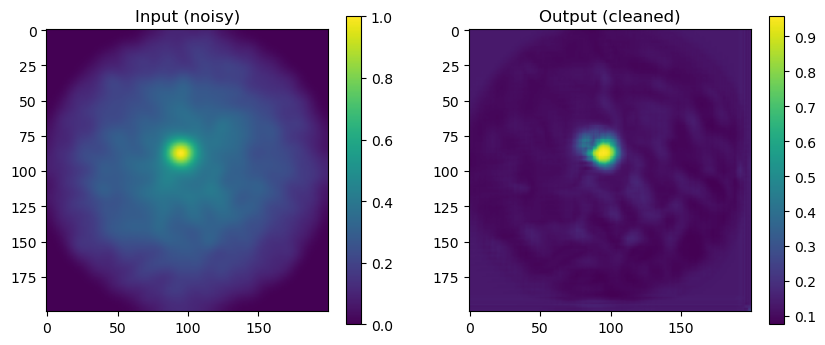

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Input (noisy)")
plt.imshow(img[0,:,:,0])
plt.colorbar()

plt.subplot(1,2,2)
plt.title("Output (cleaned)")
plt.imshow(pred[0,:,:,0])
plt.colorbar()

plt.show()

## CNN Regressor

In [3]:
import pickle
import numpy as np
import tensorflow as tf

# ===== 1. load regressor model =====
model = tf.keras.models.load_model(
    "/home/cyc/software/astroAI/models/crta_models/regressor_z20.h5"
)

print("Regressor loaded")

# ===== 2. load dataset =====
with open("/home/cyc/software/astroAI/dataset/simulations_dataset_v1/dl3_z20_irf/z20_clean_test.pickle", "rb") as f:
    ds = pickle.load(f)

print("Keys:", ds.keys())

# 用 cleaner 的输出 or noisy 输入都行（先简单用 noisy）
x = ds["DS1"]

print("Data shape:", x.shape)

# ===== 3. 取一张图 =====
img = x[0]
img = img.reshape(1, 200, 200, 1)

# ===== 4. 预测 source 位置 =====
pred = model.predict(img)

print("Predicted (normalized xy):", pred)

x_pix = pred[0][0] * 200
y_pix = pred[0][1] * 200

print("Pixel position:", x_pix, y_pix)

# ===== 传统方法（简化版）：找最亮像素 =====
counts = img[0,:,:,0]

# 找最大值位置
y_max, x_max = np.unravel_index(np.argmax(counts), counts.shape)

print("Classical (max pixel):", x_max, y_max)
print("CNN prediction:", x_pix, y_pix)

# ===== 计算误差 =====
dist = np.sqrt((x_pix - x_max)**2 + (y_pix - y_max)**2)

print("Pixel distance:", dist)

/home/cyc/miniconda3/envs/astroai/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Regressor loaded
Keys: dict_keys(['DS1', 'DS2', 'normalisation'])
Data shape: (2000, 200, 200)


I0000 00:00:1776914032.250726 1862671 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776914032.306647 1862673 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776914032.381644 1862688 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2', 16 bytes spill stores, 16 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted (normalized xy): [[0.47437158 0.43728337]]
Pixel position: 94.87431 87.45667
Classical (max pixel): 95 88
CNN prediction: 94.87431 87.45667
Pixel distance: 0.5576752837096239


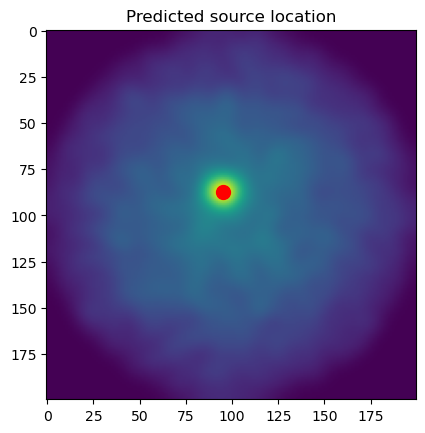

In [4]:
import matplotlib.pyplot as plt

plt.imshow(img[0,:,:,0])
plt.scatter(x_pix, y_pix, c='red', s=100)
plt.title("Predicted source location")
plt.show()

## Compare angular pointing error

## CNN clean map

/home/cyc/miniconda3/envs/astroai/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Cleaner model loaded


Regressor model loaded
Data shape: (2000, 200, 200)
Manifest shape: (2000, 9)
Generating clean maps with cleaner model...
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Predicting pixel positions with regressor model...


I0000 00:00:1776914038.365612 1864353 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776914039.219077 1864347 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 88 bytes spill stores, 84 bytes spill loads



49/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

I0000 00:00:1776914040.135633 1864616 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 32 bytes spill stores, 32 bytes spill loads



63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step
seed=   1 | pred=(94.44, 86.69) | true=(95.12, 86.91) | dx=-0.68, dy=-0.21, dist=0.71
seed=   2 | pred=(115.01, 97.96) | true=(116.38, 101.44) | dx=-1.36, dy=-3.48, dist=3.74
seed=   3 | pred=(85.09, 104.80) | true=(86.04, 105.52) | dx=-0.95, dy=-0.72, dist=1.19
seed=   4 | pred=(95.00, 104.87) | true=(63.10, 168.09) | dx=31.89, dy=-63.22, dist=70.81
seed=   5 | pred=(118.71, 130.50) | true=(140.98, 149.13) | dx=-22.26, dy=-18.63, dist=29.03
   seed      pred_x      pred_y      true_x      true_y         dx         dy  \
0     1   94.444290   86.693909   95.124060   86.906109  -0.679770  -0.212200   
1     2  115.013062   97.960052  116.377722  101.442256  -1.364660  -3.482204   
2     3   85.085739  104.799629   86.035214  105.520256  -0.949475  -0.720626   
3     4   94.996086  104.869247   63.104436  168.087938  31.891650 -63.218691   
4     5  118.712791  130.504959  140.976053  149.131291 -22.263262 -18.626332   

        dist  
0   0.712121

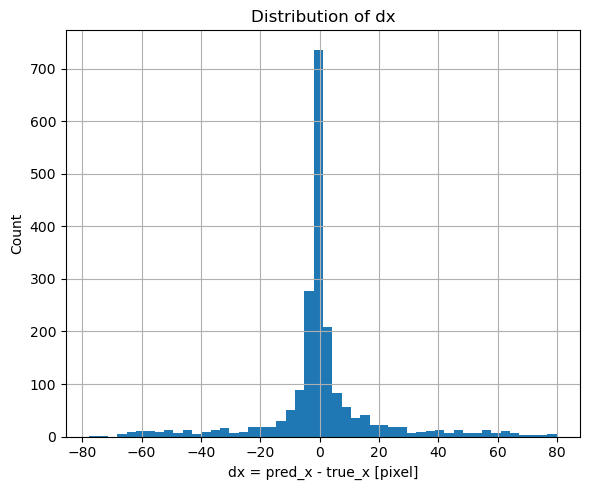

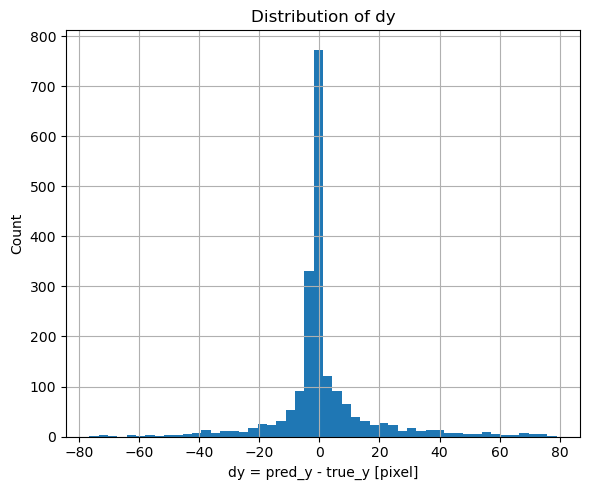

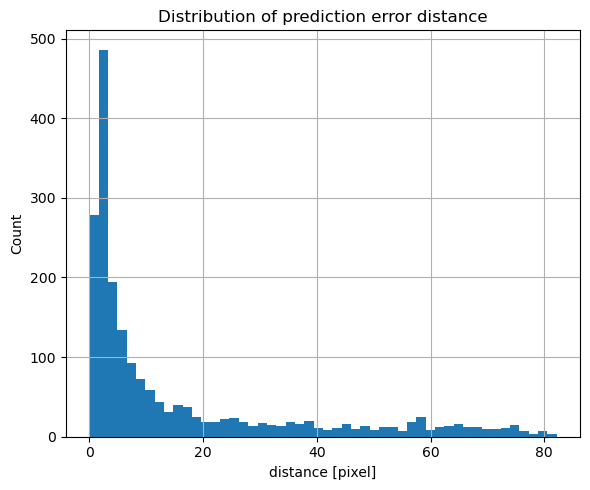

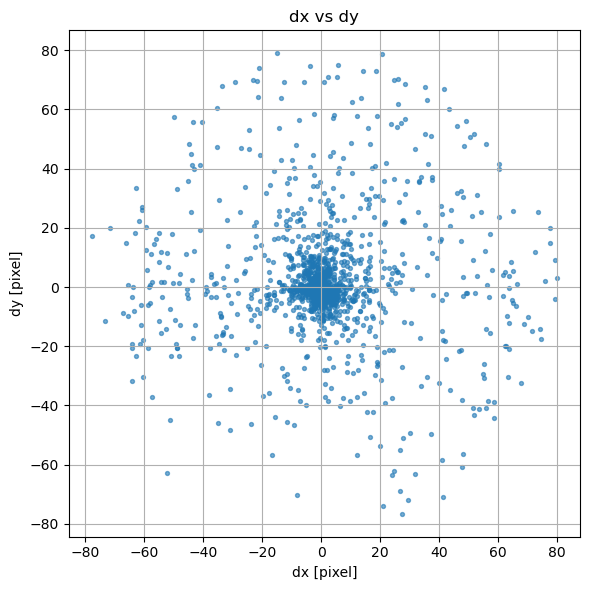

In [5]:
# CNN clean map
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
from gammapy.maps import WcsGeom

# ===== 1. 加载模型 (Cleaner & Regressor) =====
cleaner_model = tf.keras.models.load_model(
    "/home/cyc/software/astroAI/models/crta_models/cleaner_z20.h5"
)
print("Cleaner model loaded")

regressor_model = tf.keras.models.load_model(
    "/home/cyc/software/astroAI/models/crta_models/regressor_z20.h5"
)
print("Regressor model loaded")

# ===== 2. 加载数据集 =====
with open(
    "/home/cyc/software/astroAI/dataset/simulations_dataset_v1/dl3_z20_irf/z20_clean_test.pickle",
    "rb"
) as f:
    ds = pickle.load(f)

# DS1 是 noisy input
x = ds["DS1"]
print("Data shape:", x.shape)

# ===== 3. 加载 manifest =====
manifest = pd.read_csv(
    "/home/cyc/software/astroAI/dataset/simulations_dataset_v1/dl3_z20_irf/output_pairs/manifest.csv"
)
manifest = manifest.sort_values("seed").reset_index(drop=True)
print("Manifest shape:", manifest.shape)

def get_true_pixel_from_manifest(row, pixsize=0.025, width=5.0):
    ra_src = row["source_ra"]
    dec_src = row["source_dec"]
    ra_pnt = row["point_ra"]
    dec_pnt = row["point_dec"]

    geom = WcsGeom.create(
        skydir=SkyCoord(ra_pnt, dec_pnt, unit="deg", frame="icrs"),
        binsz=pixsize,
        width=(width, width),
        frame="icrs",
        proj="CAR"
    )

    coord = SkyCoord(ra_src, dec_src, unit="deg", frame="icrs")
    x_true, y_true = geom.coord_to_pix({"skycoord": coord})[:2]

    x_true = float(np.asarray(x_true).squeeze())
    y_true = float(np.asarray(y_true).squeeze())

    return x_true, y_true

# ===== 4. 推理过程 (Cleaner -> Regressor) =====
n_samples = min(2000, len(x), len(manifest))

# 准备 Noisy Input
x_input = x[:n_samples].reshape(-1, 200, 200, 1)

# 第 1 步：用 CNN (cleaner_model) 生成 clean map
print("Generating clean maps with cleaner model...")
cleaned_maps = cleaner_model.predict(x_input, verbose=1)

# 第 2 步：用生成的 clean map 作为输入，用 regressor_model 预测位置
print("Predicting pixel positions with regressor model...")
pred_all = regressor_model.predict(cleaned_maps, verbose=1)

# ===== 5. 结果处理与可视化 =====
dx_list = []
dy_list = []
dist_list = []
pred_x_list = []
pred_y_list = []
true_x_list = []
true_y_list = []
seed_list = []

for i in range(n_samples):
    seed = i + 1

    row_match = manifest[manifest["seed"] == seed]
    if len(row_match) == 0:
        print(f"[WARN] seed={seed} not found in manifest, skip")
        continue

    row = row_match.iloc[0]

    pred_x = float(pred_all[i, 0] * 200)
    pred_y = float(pred_all[i, 1] * 200)

    true_x, true_y = get_true_pixel_from_manifest(row)

    dx = pred_x - true_x
    dy = pred_y - true_y
    dist = np.sqrt(dx**2 + dy**2)

    seed_list.append(seed)
    pred_x_list.append(pred_x)
    pred_y_list.append(pred_y)
    true_x_list.append(true_x)
    true_y_list.append(true_y)
    dx_list.append(dx)
    dy_list.append(dy)
    dist_list.append(dist)

    if i < 5:
        print(
            f"seed={seed:4d} | "
            f"pred=({pred_x:.2f}, {pred_y:.2f}) | "
            f"true=({true_x:.2f}, {true_y:.2f}) | "
            f"dx={dx:.2f}, dy={dy:.2f}, dist={dist:.2f}"
        )

result_df = pd.DataFrame({
    "seed": seed_list,
    "pred_x": pred_x_list,
    "pred_y": pred_y_list,
    "true_x": true_x_list,
    "true_y": true_y_list,
    "dx": dx_list,
    "dy": dy_list,
    "dist": dist_list,
})

print(result_df.head())

# 画图
plt.figure(figsize=(6, 5))
plt.hist(dx_list, bins=50)
plt.xlabel("dx = pred_x - true_x [pixel]")
plt.ylabel("Count")
plt.title("Distribution of dx")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(dy_list, bins=50)
plt.xlabel("dy = pred_y - true_y [pixel]")
plt.ylabel("Count")
plt.title("Distribution of dy")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(dist_list, bins=50)
plt.xlabel("distance [pixel]")
plt.ylabel("Count")
plt.title("Distribution of prediction error distance")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(dx_list, dy_list, s=8, alpha=0.6)
plt.xlabel("dx [pixel]")
plt.ylabel("dy [pixel]")
plt.title("dx vs dy")
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
from scipy.optimize import curve_fit

# 定义高斯函数
def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

def fit_and_plot_distribution(data, xlabel, title, filename):
    # 1. 计算直方图的 bin 和 counts
    counts, bin_edges = np.histogram(data, bins=50, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 2. 初始猜测值 (Initial guess)
    # A 猜测为最大值，mu 猜测为均值，sigma 猜测为标准差
    p0 = [max(counts), np.mean(data), np.std(data)]
    
    # 3. 进行高斯拟合
    try:
        popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0)
        a_fit, mu_fit, sigma_fit = popt
        print(f"[{title}] Fit Result: mu={mu_fit:.4f}, sigma={sigma_fit:.4f}")
    except Exception as e:
        print(f"[{title}] Fitting failed: {e}")
        return

    # 4. 绘图
    plt.figure(figsize=(6, 5))
    plt.hist(data, bins=50, density=True, alpha=0.6, label="Data")
    
    # 绘制拟合曲线
    x_range = np.linspace(min(bin_centers), max(bin_centers), 100)
    plt.plot(x_range, gaussian(x_range, *popt), 'r-', lw=2, 
             label=f'Gaussian Fit:\n$\mu={mu_fit:.3f}, \sigma={sigma_fit:.3f}$')
    
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# 分别对 dx, dy, dist 进行拟合
fit_and_plot_distribution(dx_list, "dx [pixel]", "Distribution of dx", "dx_dist_fit.png")
fit_and_plot_distribution(dy_list, "dy [pixel]", "Distribution of dy", "dy_dist_fit.png")

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1860628/2660475434.py:32: SyntaxWarning: invalid escape sequence '\m'
  label=f'Gaussian Fit:\n$\mu={mu_fit:.3f}, \sigma={sigma_fit:.3f}$')
/tmp/ipykernel_1860628/2660475434.py:32: SyntaxWarning: invalid escape sequence '\s'
  label=f'Gaussian Fit:\n$\mu={mu_fit:.3f}, \sigma={sigma_fit:.3f}$')


[Distribution of dx] Fit Result: mu=-0.6963, sigma=2.1659
[Distribution of dy] Fit Result: mu=-0.9333, sigma=1.9380


#### Error is

In [7]:
np.sqrt(2.1659*2.1659+1.9380*1.9380)*0.025

np.float64(0.07265916498453584)

### Conventional clean map

/home/cyc/miniconda3/envs/astroai/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Regressor loaded
Data shape: (2000, 200, 200)
Manifest shape: (2000, 9)
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
seed=   1 | pred=(94.31, 87.06) | true=(95.12, 86.91) | dx=-0.81, dy=0.15, dist=0.83
seed=   2 | pred=(115.11, 99.06) | true=(116.38, 101.44) | dx=-1.27, dy=-2.38, dist=2.70
seed=   3 | pred=(85.76, 104.91) | true=(86.04, 105.52) | dx=-0.28, dy=-0.61, dist=0.67
seed=   4 | pred=(129.22, 118.86) | true=(63.10, 168.09) | dx=66.12, dy=-49.23, dist=82.43
seed=   5 | pred=(133.50, 148.00) | true=(140.98, 149.13) | dx=-7.47, dy=-1.13, dist=7.56
   seed      pred_x      pred_y      true_x      true_y         dx         dy  \
0     1   94.309120   87.057640   95.124060   86.906109  -0.814940   0.151531   
1     2  115.112152   99.062332  116.377722  101.442256  -1.265570  -2.379924   
2     3   85.756447  104.909241   86.035214  105.520256  -0.278767  -0.611015   
3     4  129.222412  118.855751   63.104436  168.087938  66.117976 -49.232187   
4     5  133.501297  147.998856  140.9760

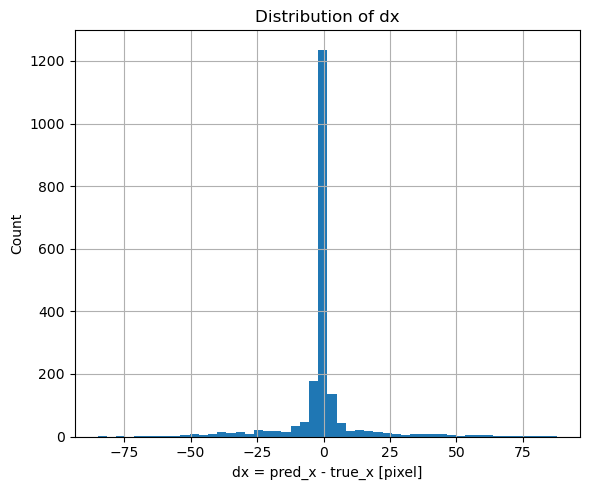

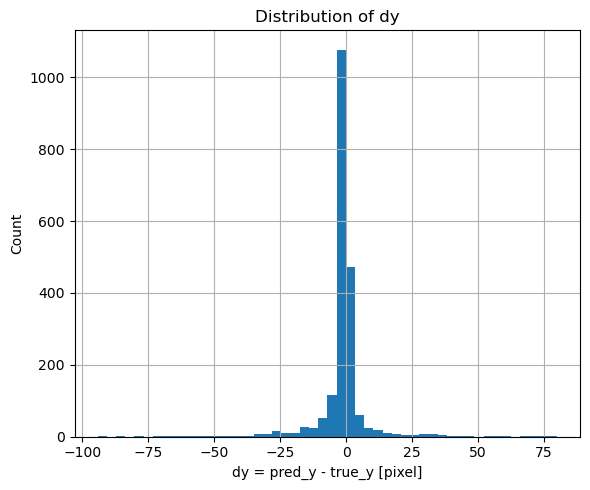

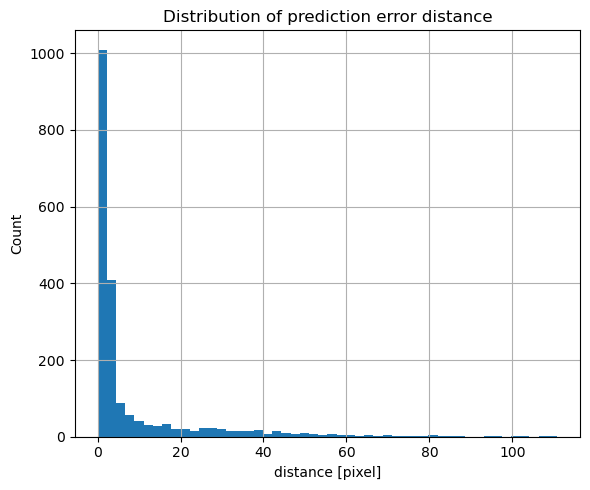

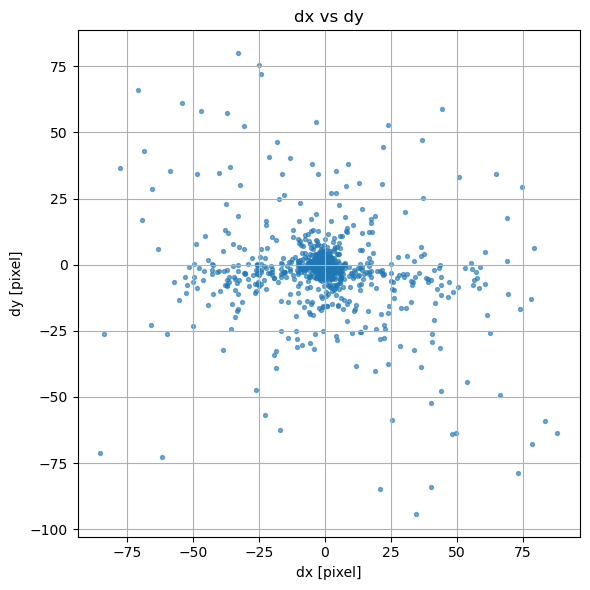

In [8]:
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
from gammapy.maps import WcsGeom

# 1. load model
model = tf.keras.models.load_model(
    "/home/cyc/software/astroAI/models/crta_models/regressor_z20.h5"
)
print("Regressor loaded")

# 2. load dataset
with open(
    "/home/cyc/software/astroAI/dataset/simulations_dataset_v1/dl3_z20_irf/z20_clean_test.pickle",
    "rb"
) as f:
    ds = pickle.load(f)

x = ds["DS2"]# DS1 for noisy map, DS2 for clean map make by conventional method
print("Data shape:", x.shape)

# 3. load manifest
manifest = pd.read_csv(
    "/home/cyc/software/astroAI/dataset/simulations_dataset_v1/dl3_z20_irf/output_pairs/manifest.csv"
)
manifest = manifest.sort_values("seed").reset_index(drop=True)
print("Manifest shape:", manifest.shape)

def get_true_pixel_from_manifest(row, pixsize=0.025, width=5.0):
    ra_src = row["source_ra"]
    dec_src = row["source_dec"]
    ra_pnt = row["point_ra"]
    dec_pnt = row["point_dec"]

    geom = WcsGeom.create(
        skydir=SkyCoord(ra_pnt, dec_pnt, unit="deg", frame="icrs"),
        binsz=pixsize,
        width=(width, width),
        frame="icrs",
        proj="CAR"
    )

    coord = SkyCoord(ra_src, dec_src, unit="deg", frame="icrs")
    x_true, y_true = geom.coord_to_pix({"skycoord": coord})[:2]

    x_true = float(np.asarray(x_true).squeeze())
    y_true = float(np.asarray(y_true).squeeze())

    return x_true, y_true

dx_list = []
dy_list = []
dist_list = []
pred_x_list = []
pred_y_list = []
true_x_list = []
true_y_list = []
seed_list = []

n_samples = min(2000, len(x), len(manifest))

# 一次性预测，避免 retracing
x_input = x[:n_samples].reshape(-1, 200, 200, 1)
pred_all = model.predict(x_input, verbose=1)

for i in range(n_samples):
    seed = i + 1

    row_match = manifest[manifest["seed"] == seed]
    if len(row_match) == 0:
        print(f"[WARN] seed={seed} not found in manifest, skip")
        continue

    row = row_match.iloc[0]

    pred_x = float(pred_all[i, 0] * 200)
    pred_y = float(pred_all[i, 1] * 200)

    true_x, true_y = get_true_pixel_from_manifest(row)

    dx = pred_x - true_x
    dy = pred_y - true_y
    dist = np.sqrt(dx**2 + dy**2)

    seed_list.append(seed)
    pred_x_list.append(pred_x)
    pred_y_list.append(pred_y)
    true_x_list.append(true_x)
    true_y_list.append(true_y)
    dx_list.append(dx)
    dy_list.append(dy)
    dist_list.append(dist)

    if i < 5:
        print(
            f"seed={seed:4d} | "
            f"pred=({pred_x:.2f}, {pred_y:.2f}) | "
            f"true=({true_x:.2f}, {true_y:.2f}) | "
            f"dx={dx:.2f}, dy={dy:.2f}, dist={dist:.2f}"
        )

result_df = pd.DataFrame({
    "seed": seed_list,
    "pred_x": pred_x_list,
    "pred_y": pred_y_list,
    "true_x": true_x_list,
    "true_y": true_y_list,
    "dx": dx_list,
    "dy": dy_list,
    "dist": dist_list,
})

print(result_df.head())

plt.figure(figsize=(6, 5))
plt.hist(dx_list, bins=50)
plt.xlabel("dx = pred_x - true_x [pixel]")
plt.ylabel("Count")
plt.title("Distribution of dx")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(dy_list, bins=50)
plt.xlabel("dy = pred_y - true_y [pixel]")
plt.ylabel("Count")
plt.title("Distribution of dy")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(dist_list, bins=50)
plt.xlabel("distance [pixel]")
plt.ylabel("Count")
plt.title("Distribution of prediction error distance")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(dx_list, dy_list, s=8, alpha=0.6)
plt.xlabel("dx [pixel]")
plt.ylabel("dy [pixel]")
plt.title("dx vs dy")
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
from scipy.optimize import curve_fit

# 定义高斯函数
def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

def fit_and_plot_distribution(data, xlabel, title, filename):
    # 1. 计算直方图的 bin 和 counts
    counts, bin_edges = np.histogram(data, bins=50, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 2. 初始猜测值 (Initial guess)
    # A 猜测为最大值，mu 猜测为均值，sigma 猜测为标准差
    p0 = [max(counts), np.mean(data), np.std(data)]
    
    # 3. 进行高斯拟合
    try:
        popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0)
        a_fit, mu_fit, sigma_fit = popt
        print(f"[{title}] Fit Result: mu={mu_fit:.4f}, sigma={sigma_fit:.4f}")
    except Exception as e:
        print(f"[{title}] Fitting failed: {e}")
        return

    # 4. 绘图
    plt.figure(figsize=(6, 5))
    plt.hist(data, bins=50, density=True, alpha=0.6, label="Data")
    
    # 绘制拟合曲线
    x_range = np.linspace(min(bin_centers), max(bin_centers), 100)
    plt.plot(x_range, gaussian(x_range, *popt), 'r-', lw=2, 
             label=f'Gaussian Fit:\n$\mu={mu_fit:.3f}, \sigma={sigma_fit:.3f}$')
    
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# 分别对 dx, dy, dist 进行拟合
fit_and_plot_distribution(dx_list, "dx [pixel]", "Distribution of dx", "dx_dist_fit.png")
fit_and_plot_distribution(dy_list, "dy [pixel]", "Distribution of dy", "dy_dist_fit.png")

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1860628/2660475434.py:32: SyntaxWarning: invalid escape sequence '\m'
  label=f'Gaussian Fit:\n$\mu={mu_fit:.3f}, \sigma={sigma_fit:.3f}$')
/tmp/ipykernel_1860628/2660475434.py:32: SyntaxWarning: invalid escape sequence '\s'
  label=f'Gaussian Fit:\n$\mu={mu_fit:.3f}, \sigma={sigma_fit:.3f}$')


[Distribution of dx] Fit Result: mu=-0.4125, sigma=-1.6970
[Distribution of dy] Fit Result: mu=-1.1115, sigma=2.0120


#### Error is

In [10]:
np.sqrt(1.6970*1.6970+2.0120*2.0120)*0.025

np.float64(0.06580251230006344)

### Noisy map

/home/cyc/miniconda3/envs/astroai/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Regressor loaded
Data shape: (2000, 200, 200)
Manifest shape: (2000, 9)
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
seed=   1 | pred=(94.87, 87.46) | true=(95.12, 86.91) | dx=-0.25, dy=0.55, dist=0.60
seed=   2 | pred=(115.00, 99.19) | true=(116.38, 101.44) | dx=-1.38, dy=-2.25, dist=2.64
seed=   3 | pred=(85.97, 105.04) | true=(86.04, 105.52) | dx=-0.06, dy=-0.48, dist=0.49
seed=   4 | pred=(59.25, 155.45) | true=(63.10, 168.09) | dx=-3.86, dy=-12.64, dist=13.21
seed=   5 | pred=(141.50, 143.92) | true=(140.98, 149.13) | dx=0.52, dy=-5.21, dist=5.23
   seed      pred_x      pred_y      true_x      true_y        dx         dy  \
0     1   94.872871   87.456108   95.124060   86.906109 -0.251189   0.549999   
1     2  115.000511   99.190453  116.377722  101.442256 -1.377210  -2.251804   
2     3   85.974464  105.038620   86.035214  105.520256 -0.060750  -0.481636   
3     4   59.245510  155.452209   63.104436  168.087938 -3.858926 -12.635729   
4     5  141.496292  143.923462  140.976053  149

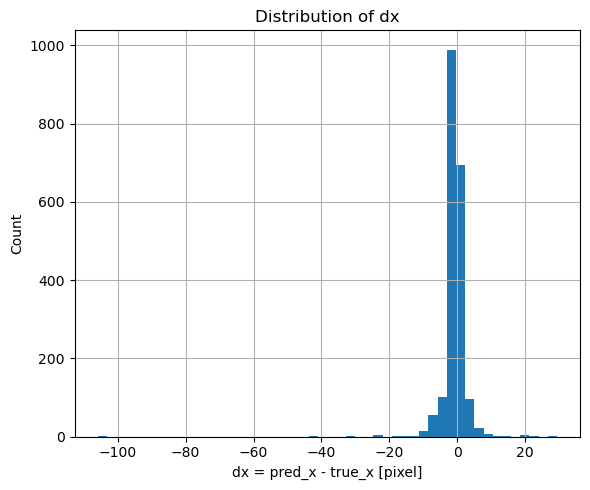

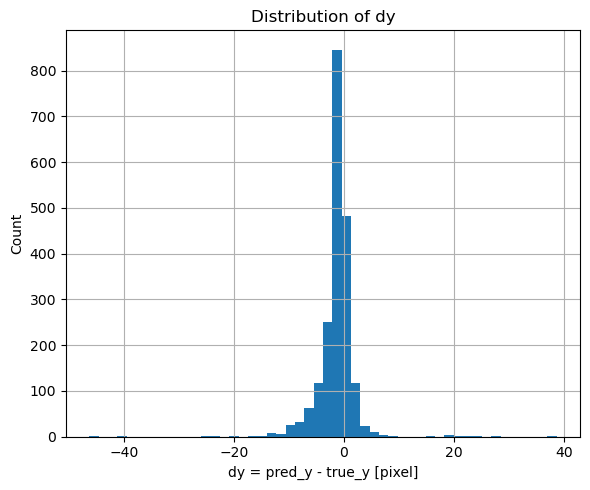

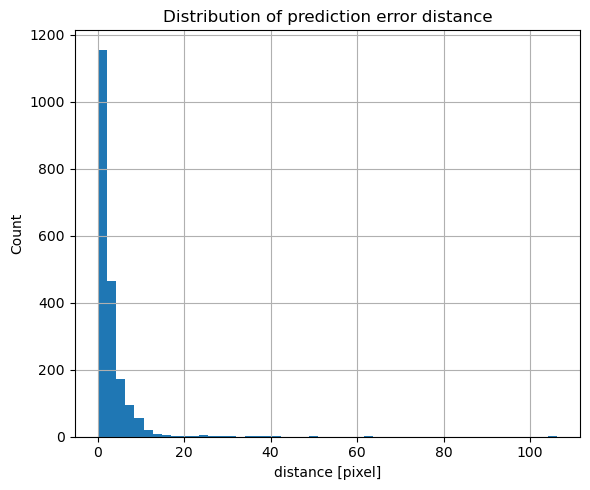

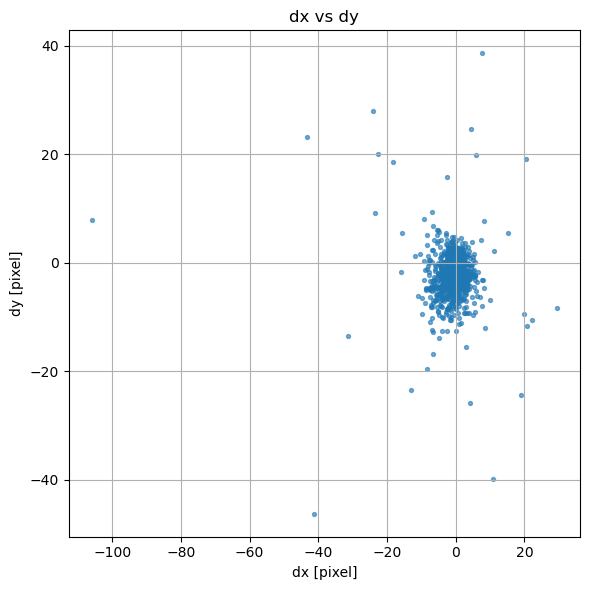

In [11]:
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
from gammapy.maps import WcsGeom

# 1. load model
model = tf.keras.models.load_model(
    "/home/cyc/software/astroAI/models/crta_models/regressor_z20.h5"
)
print("Regressor loaded")

# 2. load dataset
with open(
    "/home/cyc/software/astroAI/dataset/simulations_dataset_v1/dl3_z20_irf/z20_clean_test.pickle",
    "rb"
) as f:
    ds = pickle.load(f)

x = ds["DS1"]# DS1 for noisy map, DS2 for clean map make by conventional method
print("Data shape:", x.shape)

# 3. load manifest
manifest = pd.read_csv(
    "/home/cyc/software/astroAI/dataset/simulations_dataset_v1/dl3_z20_irf/output_pairs/manifest.csv"
)
manifest = manifest.sort_values("seed").reset_index(drop=True)
print("Manifest shape:", manifest.shape)

def get_true_pixel_from_manifest(row, pixsize=0.025, width=5.0):
    ra_src = row["source_ra"]
    dec_src = row["source_dec"]
    ra_pnt = row["point_ra"]
    dec_pnt = row["point_dec"]

    geom = WcsGeom.create(
        skydir=SkyCoord(ra_pnt, dec_pnt, unit="deg", frame="icrs"),
        binsz=pixsize,
        width=(width, width),
        frame="icrs",
        proj="CAR"
    )

    coord = SkyCoord(ra_src, dec_src, unit="deg", frame="icrs")
    x_true, y_true = geom.coord_to_pix({"skycoord": coord})[:2]

    x_true = float(np.asarray(x_true).squeeze())
    y_true = float(np.asarray(y_true).squeeze())

    return x_true, y_true

dx_list = []
dy_list = []
dist_list = []
pred_x_list = []
pred_y_list = []
true_x_list = []
true_y_list = []
seed_list = []

n_samples = min(2000, len(x), len(manifest))

# 一次性预测，避免 retracing
x_input = x[:n_samples].reshape(-1, 200, 200, 1)
pred_all = model.predict(x_input, verbose=1)

for i in range(n_samples):
    seed = i + 1

    row_match = manifest[manifest["seed"] == seed]
    if len(row_match) == 0:
        print(f"[WARN] seed={seed} not found in manifest, skip")
        continue

    row = row_match.iloc[0]

    pred_x = float(pred_all[i, 0] * 200)
    pred_y = float(pred_all[i, 1] * 200)

    true_x, true_y = get_true_pixel_from_manifest(row)

    dx = pred_x - true_x
    dy = pred_y - true_y
    dist = np.sqrt(dx**2 + dy**2)

    seed_list.append(seed)
    pred_x_list.append(pred_x)
    pred_y_list.append(pred_y)
    true_x_list.append(true_x)
    true_y_list.append(true_y)
    dx_list.append(dx)
    dy_list.append(dy)
    dist_list.append(dist)

    if i < 5:
        print(
            f"seed={seed:4d} | "
            f"pred=({pred_x:.2f}, {pred_y:.2f}) | "
            f"true=({true_x:.2f}, {true_y:.2f}) | "
            f"dx={dx:.2f}, dy={dy:.2f}, dist={dist:.2f}"
        )

result_df = pd.DataFrame({
    "seed": seed_list,
    "pred_x": pred_x_list,
    "pred_y": pred_y_list,
    "true_x": true_x_list,
    "true_y": true_y_list,
    "dx": dx_list,
    "dy": dy_list,
    "dist": dist_list,
})

print(result_df.head())

plt.figure(figsize=(6, 5))
plt.hist(dx_list, bins=50)
plt.xlabel("dx = pred_x - true_x [pixel]")
plt.ylabel("Count")
plt.title("Distribution of dx")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(dy_list, bins=50)
plt.xlabel("dy = pred_y - true_y [pixel]")
plt.ylabel("Count")
plt.title("Distribution of dy")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(dist_list, bins=50)
plt.xlabel("distance [pixel]")
plt.ylabel("Count")
plt.title("Distribution of prediction error distance")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(dx_list, dy_list, s=8, alpha=0.6)
plt.xlabel("dx [pixel]")
plt.ylabel("dy [pixel]")
plt.title("dx vs dy")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
from scipy.optimize import curve_fit

# 定义高斯函数
def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

def fit_and_plot_distribution(data, xlabel, title, filename):
    # 1. 计算直方图的 bin 和 counts
    counts, bin_edges = np.histogram(data, bins=50, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 2. 初始猜测值 (Initial guess)
    # A 猜测为最大值，mu 猜测为均值，sigma 猜测为标准差
    p0 = [max(counts), np.mean(data), np.std(data)]
    
    # 3. 进行高斯拟合
    try:
        popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0)
        a_fit, mu_fit, sigma_fit = popt
        print(f"[{title}] Fit Result: mu={mu_fit:.4f}, sigma={sigma_fit:.4f}")
    except Exception as e:
        print(f"[{title}] Fitting failed: {e}")
        return

    # 4. 绘图
    plt.figure(figsize=(6, 5))
    plt.hist(data, bins=50, density=True, alpha=0.6, label="Data")
    
    # 绘制拟合曲线
    x_range = np.linspace(min(bin_centers), max(bin_centers), 100)
    plt.plot(x_range, gaussian(x_range, *popt), 'r-', lw=2, 
             label=f'Gaussian Fit:\n$\mu={mu_fit:.3f}, \sigma={sigma_fit:.3f}$')
    
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# 分别对 dx, dy, dist 进行拟合
fit_and_plot_distribution(dx_list, "dx [pixel]", "Distribution of dx", "dx_dist_fit.png")
fit_and_plot_distribution(dy_list, "dy [pixel]", "Distribution of dy", "dy_dist_fit.png")

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1860628/2660475434.py:32: SyntaxWarning: invalid escape sequence '\m'
  label=f'Gaussian Fit:\n$\mu={mu_fit:.3f}, \sigma={sigma_fit:.3f}$')
/tmp/ipykernel_1860628/2660475434.py:32: SyntaxWarning: invalid escape sequence '\s'
  label=f'Gaussian Fit:\n$\mu={mu_fit:.3f}, \sigma={sigma_fit:.3f}$')


[Distribution of dx] Fit Result: mu=-0.7205, sigma=1.7444
[Distribution of dy] Fit Result: mu=-0.9655, sigma=1.3608


In [13]:
#### Error is:

In [14]:
np.sqrt(1.7444*1.7444+1.3608*1.3608)*0.025

np.float64(0.055309967456146636)